<!-- codex-purpose-v2 -->
# 01 - Dataset Audit And EDA

## Purpose
Audit the raw durian leaf dataset before modeling. This notebook checks class
balance, image quality, split consistency, and visual/color characteristics.

## Research Thinking
- The later segmentation pipeline depends on classifier attention and pseudo
  labels, so weak data assumptions can propagate through the whole thesis.
- Lighting, background leakage, healthy green regions, and lesion color
  variation explain why simple GradCAM masks are not enough.
- The audit supports the final scope: five-class classification plus binary
  lesion segmentation, rather than multi-class lesion segmentation.

## Inputs / Outputs
- Input: `notebooks/data/raw/{train,val,test}/`.
- Output: dataset statistics, manifest files, and EDA figures.

## How To Read The Result
Use this notebook to justify dataset size, split policy, preprocessing, and the
biological motivation for later color-prior filtering.


# 01 · Data Exploration

Notebook này khám phá dataset ảnh bệnh lá sầu riêng trước khi đưa vào huấn luyện. Mục tiêu là hiểu rõ dữ liệu mình đang làm việc với — không chỉ về con số mà còn về đặc trưng hình ảnh của từng lớp bệnh.

---

**Processed:**

1. **Load & kiểm tra dataset** — xác nhận số lượng ảnh, số lớp, cấu trúc thư mục
2. **Phân phối lớp** — so sánh số lượng và tỉ lệ giữa 5 lớp bệnh, kiểm tra mức độ mất cân bằng
3. **Phân chia train / val / test** — xác nhận tỉ lệ 70/10/20 và tính đồng đều per-class
4. **Ảnh mẫu** — xem trực tiếp đặc điểm hình thái của từng loại bệnh
5. **Phân tích màu sắc RGB** — histogram và giá trị trung bình từng kênh màu theo lớp
6. **Thống kê ảnh** — kích thước file, phân phối độ sáng, KDE theo lớp
7. **Kiểm tra pipeline** — đảm bảo DataLoader hoạt động đúng trước khi chạy training

**Output:** Các figure lưu tại `visualizations/eda/` · Thống kê lưu tại `data/processed/`

## Setup and Imports

In [1]:
import sys
import os
proj_root = r'E:\Master\thesis-clean'
sys.path.insert(0, proj_root)
sys.path.insert(0, os.path.join(proj_root, 'utils'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import json
import hashlib
from datetime import datetime
from IPython.display import display

from utils.preprocessing import DataLoader

torch.manual_seed(42)
np.random.seed(42)

plt.style.use('default')
sns.set_palette("husl")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: Quadro M1000M


## Data Directory Setup

In [2]:
# Define data directories
DATA_RAW_DIR = proj_root + "/notebooks/data/raw"
DATA_PROCESSED_DIR = "data/processed"
VISUALIZATION_DIR = "visualizations"

# Create directories if they don't exist
os.makedirs(DATA_PROCESSED_DIR, exist_ok=True)
os.makedirs(VISUALIZATION_DIR, exist_ok=True)

print(f"Raw data directory: {DATA_RAW_DIR}")
print(f"Processed data directory: {DATA_PROCESSED_DIR}")
print(f"Visualization directory: {VISUALIZATION_DIR}")

Raw data directory: E:\Master\thesis-clean/notebooks/data/raw
Processed data directory: data/processed
Visualization directory: visualizations


## Dataset Loading and Validation

In [3]:
# Initialize data loader
data_loader = DataLoader(
    data_dir=DATA_RAW_DIR,
    batch_size=32,
    image_size=(224, 224),
    random_seed=42
)

print("DataLoader initialized successfully")
print(f"Batch size: {data_loader.batch_size}")
print(f"Image size: {data_loader.image_size}")

DataLoader initialized successfully
Batch size: 32
Image size: (224, 224)


In [4]:
# Load and validate dataset
try:
    datasets = data_loader.load_dataset()
    print("✅ Dataset loaded successfully!")
    print(f"Train set: {len(datasets['train'])} images")
    print(f"Validation set: {len(datasets['val'])} images")
    print(f"Test set: {len(datasets['test'])} images")
    print(f"Total: {sum(len(v) for v in datasets.values())} images")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")
    print("Please check that your data is organized correctly in data/raw/ with class subdirectories.")

✅ Dataset loaded successfully!
Train set: 3104 images
Validation set: 443 images
Test set: 890 images
Total: 4437 images


---
**Nhận xét — Load và kiểm tra dữ liệu:**

- **Quan sát chính:** Notebook load thành công **4,437 ảnh**, gồm **3,104 ảnh train**, **443 ảnh validation** và **890 ảnh test**.
- **Ý nghĩa:** Cấu trúc `raw/train`, `raw/val`, `raw/test` đã được DataLoader nhận diện đúng; không có lỗi dừng ở bước đọc dataset ban đầu.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Có thể tiếp tục dùng split hiện có thay vì chia lại ngẫu nhiên, giúp các notebook sau tái lập đúng cùng một tập dữ liệu.
- **Điểm cần lưu ý:** Cell này mới xác nhận số lượng object được DataLoader tạo ra; các kiểm tra sâu hơn như file hỏng, duplicate, leakage giữa split và thống kê ảnh toàn bộ dataset được bổ sung ở phần manifest bên dưới.

## Class Distribution Analysis

In [5]:
# Get class distribution
class_distribution = data_loader.get_class_distribution()
print("Class distribution:")
for class_id, count in class_distribution.items():
    print(f"  Class {class_id}: {count} images")

# Check if we have the expected 5 classes
expected_classes = 5
actual_classes = len(class_distribution)
print(f"\nExpected classes: {expected_classes}")
print(f"Actual classes: {actual_classes}")

if actual_classes == expected_classes:
    print("✅ Correct number of classes detected")
else:
    print(f"⚠️  Warning: Expected {expected_classes} classes, found {actual_classes}")

Class distribution:
  Class 0: 733 images
  Class 1: 913 images
  Class 2: 976 images
  Class 3: 937 images
  Class 4: 878 images

Expected classes: 5
Actual classes: 5
✅ Correct number of classes detected


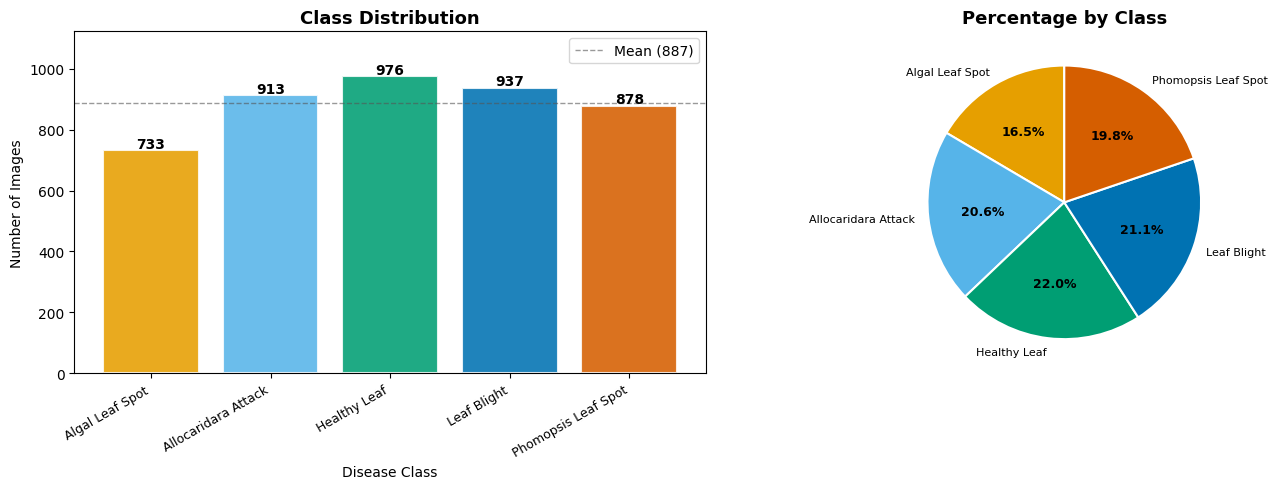

Saved → visualizations/eda/class_distribution.png
Imbalance ratio: 1.33
Most: Healthy Leaf (976), Least: Algal Leaf Spot (733)


In [6]:
# Define class metadata (consistent with thesis)
CLASS_NAMES  = ["ALGAL_LEAF_SPOT", "ALLOCARIDARA_ATTACK", "HEALTHY_LEAF", "LEAF_BLIGHT", "PHOMOPSIS_LEAF_SPOT"]
CLASS_LABELS = ["Algal Leaf Spot", "Allocaridara Attack", "Healthy Leaf", "Leaf Blight", "Phomopsis Leaf Spot"]

# Okabe-Ito palette — colorblind-safe, recommended by Nature Methods & IEEE
CLASS_COLORS = ["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00"]

CLASS_COUNTS = [class_distribution[i] for i in range(len(class_distribution))]
TOTAL = sum(CLASS_COUNTS)

# Output directory for all EDA figures
EDA_VIZ_DIR = os.path.join(VISUALIZATION_DIR, "eda")
os.makedirs(EDA_VIZ_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars = ax.bar(CLASS_LABELS, CLASS_COUNTS, color=CLASS_COLORS, edgecolor="white", linewidth=1.5, alpha=0.88)
ax.set_title("Class Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Disease Class")
ax.set_ylabel("Number of Images")
ax.set_xticks(range(len(CLASS_LABELS)))
ax.set_xticklabels(CLASS_LABELS, rotation=30, ha="right", fontsize=9)
for bar, cnt in zip(bars, CLASS_COUNTS):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8, str(cnt),
            ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, max(CLASS_COUNTS) * 1.15)
ax.axhline(y=TOTAL // 5, color="#555555", linestyle="--", linewidth=1, alpha=0.6,
           label=f"Mean ({TOTAL // 5})")
ax.legend()

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    CLASS_COUNTS, labels=CLASS_LABELS, colors=CLASS_COLORS,
    autopct="%1.1f%%", startangle=90, textprops={"fontsize": 8},
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight("bold")
ax2.set_title("Percentage by Class", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(EDA_VIZ_DIR, "class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → visualizations/eda/class_distribution.png")
print(f"Imbalance ratio: {max(CLASS_COUNTS)/min(CLASS_COUNTS):.2f}")
print(f"Most: Healthy Leaf ({max(CLASS_COUNTS)}), Least: Algal Leaf Spot ({min(CLASS_COUNTS)})")

---
**Nhận xét — Phân phối lớp:**

- **Quan sát chính:** Dataset có **4,437 ảnh** thuộc đúng **5 lớp**. Lớp nhiều nhất là **Healthy Leaf** với **976 ảnh (22.0%)**, lớp ít nhất là **Algal Leaf Spot** với **733 ảnh (16.5%)**; các lớp còn lại nằm trong khoảng **878-937 ảnh**.
- **Ý nghĩa:** **Imbalance ratio = 1.33**, tức lớp lớn nhất chỉ nhiều hơn lớp nhỏ nhất khoảng 33%. Đây là mức lệch nhẹ đối với bài toán classification 5 lớp.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Chưa cần oversampling mạnh. Khi huấn luyện classifier, vẫn nên báo cáo **macro-F1** và per-class recall để đảm bảo lớp nhỏ nhất (*Algal Leaf Spot*) không bị bỏ qua.
- **Điểm cần lưu ý:** Class weight có thể chưa cần ở baseline, nhưng nên quyết định lại sau khi xem confusion matrix; cặp lớp đốm lá có hình thái gần nhau có thể gây lỗi dù số lượng lớp cân bằng.

---
## Dataset Manifest and Integrity Audit

In [7]:
# Build a full image-level manifest for integrity, leakage, and feature audits
manifest_records = []
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

for split, image_objects in datasets.items():
    for img_obj in image_objects:
        img_path = Path(img_obj.image_path)
        record = {
            "split": split,
            "class_id": img_obj.class_label,
            "class_name": CLASS_NAMES[img_obj.class_label],
            "class_label": CLASS_LABELS[img_obj.class_label],
            "filename": img_path.name,
            "path": str(img_path),
            "extension": img_path.suffix.lower(),
            "exists": img_path.exists(),
            "readable": False,
            "error": "",
            "file_size_kb": np.nan,
            "width": np.nan,
            "height": np.nan,
            "aspect_ratio": np.nan,
            "mode": None,
            "brightness": np.nan,
            "contrast": np.nan,
            "mean_r": np.nan,
            "mean_g": np.nan,
            "mean_b": np.nan,
            "green_excess": np.nan,
            "saturation": np.nan,
            "md5": None,
        }
        try:
            if img_path.exists():
                record["file_size_kb"] = img_path.stat().st_size / 1024
                hash_md5 = hashlib.md5()
                with open(img_path, "rb") as f:
                    for chunk in iter(lambda: f.read(1024 * 1024), b""):
                        hash_md5.update(chunk)
                record["md5"] = hash_md5.hexdigest()

            with Image.open(img_path) as img:
                img_rgb = img.convert("RGB")
                arr = np.asarray(img_rgb, dtype=np.float32)
                record.update({
                    "readable": True,
                    "width": img_rgb.width,
                    "height": img_rgb.height,
                    "aspect_ratio": img_rgb.width / img_rgb.height,
                    "mode": img.mode,
                    "brightness": arr.mean(),
                    "contrast": arr.std(),
                    "mean_r": arr[:, :, 0].mean(),
                    "mean_g": arr[:, :, 1].mean(),
                    "mean_b": arr[:, :, 2].mean(),
                    "green_excess": (2 * arr[:, :, 1] - arr[:, :, 0] - arr[:, :, 2]).mean(),
                    "saturation": (arr.max(axis=2) - arr.min(axis=2)).mean(),
                })
        except Exception as exc:
            record["error"] = str(exc)

        manifest_records.append(record)

manifest_df = pd.DataFrame(manifest_records)
manifest_path = os.path.join(DATA_PROCESSED_DIR, "image_manifest.csv")
manifest_df.to_csv(manifest_path, index=False)

split_class_counts = pd.crosstab(manifest_df["class_label"], manifest_df["split"])
split_class_counts = split_class_counts[["train", "val", "test"]]
split_class_counts["total"] = split_class_counts.sum(axis=1)
split_class_pct = (split_class_counts.div(split_class_counts["total"], axis=0) * 100).round(1)

integrity_summary = pd.DataFrame({
    "Metric": [
        "Total manifest rows", "Missing files", "Unreadable files", "Non-image extensions",
        "Unique image sizes", "Exact duplicate hash groups", "Images inside duplicate hash groups",
        "Cross-split exact hash leakage groups", "Cross-split filename overlap groups"
    ],
    "Value": [
        len(manifest_df),
        int((~manifest_df["exists"]).sum()),
        int((~manifest_df["readable"]).sum()),
        int((~manifest_df["extension"].isin(image_extensions)).sum()),
        manifest_df[["width", "height"]].drop_duplicates().shape[0],
        int((manifest_df.groupby("md5").size() > 1).sum()),
        int(manifest_df[manifest_df.duplicated("md5", keep=False)].shape[0]),
        int((manifest_df.groupby("md5")["split"].nunique() > 1).sum()),
        int((manifest_df.groupby("filename")["split"].nunique() > 1).sum()),
    ]
})

display(integrity_summary)
display(split_class_counts)
display(split_class_pct[["train", "val", "test"]])
print(f"Saved manifest → {manifest_path}")

,Metric,Value
0,Total manifest rows,4437
1,Missing files,0
2,Unreadable files,0
3,Non-image extensions,0
4,Unique image sizes,1
5,Exact duplicate hash groups,1
6,Images inside duplicate hash groups,2
7,Cross-split exact hash leakage groups,0
8,Cross-split filename overlap groups,0


split,train,val,test,total
class_label,,,,
Algal Leaf Spot,513,73,147,733
Allocaridara Attack,639,91,183,913
Healthy Leaf,683,97,196,976
Leaf Blight,655,94,188,937
Phomopsis Leaf Spot,614,88,176,878


split,train,val,test
class_label,,,
Algal Leaf Spot,70.0,10.0,20.1
Allocaridara Attack,70.0,10.0,20.0
Healthy Leaf,70.0,9.9,20.1
Leaf Blight,69.9,10.0,20.1
Phomopsis Leaf Spot,69.9,10.0,20.0


Saved manifest → data/processed\image_manifest.csv


**Nhận xét — Manifest, chất lượng file và phân bố split theo lớp:**

- **Quan sát chính:** Manifest có đúng **4,437 dòng**, khớp tổng số ảnh DataLoader đã load. Không có file thiếu, không có file không đọc được và không có extension ngoài nhóm ảnh hợp lệ. Toàn bộ ảnh có cùng kích thước **224x224**.
- **Ý nghĩa:** Dataset đã được chuẩn hóa kích thước trước khi EDA; rủi ro lỗi runtime do file hỏng hoặc kích thước bất thường là rất thấp.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Có thể dùng pipeline resize/normalize hiện tại như một bước nhất quán. Vì ảnh đã là 224x224, augmentation không nên phụ thuộc vào crop quá mạnh khiến mất vùng bệnh nhỏ.
- **Điểm cần lưu ý:** Bảng per-class split cho thấy mỗi lớp giữ gần đúng **70/10/20**: ví dụ *Healthy Leaf* là **683/97/196**, *Algal Leaf Spot* là **513/73/147**. Đây là split đã stratify tốt, nhưng vẫn cần kiểm tra duplicate/leakage bằng hash ở cell kế tiếp.

In [8]:
# Exact duplicate and leakage checks
exact_duplicate_images = manifest_df[manifest_df.duplicated("md5", keep=False)].sort_values(["md5", "split", "class_label", "filename"])

cross_split_hash_leakage = (
    manifest_df.groupby("md5")
    .agg(
        n_images=("path", "size"),
        n_splits=("split", "nunique"),
        splits=("split", lambda x: ", ".join(sorted(set(x)))),
        classes=("class_label", lambda x: ", ".join(sorted(set(x)))),
        filenames=("filename", lambda x: ", ".join(sorted(x))),
    )
    .reset_index()
)
cross_split_hash_leakage = cross_split_hash_leakage[cross_split_hash_leakage["n_splits"] > 1]

cross_split_filename_overlap = (
    manifest_df.groupby("filename")
    .agg(
        n_images=("path", "size"),
        n_splits=("split", "nunique"),
        splits=("split", lambda x: ", ".join(sorted(set(x)))),
        classes=("class_label", lambda x: ", ".join(sorted(set(x)))),
    )
    .reset_index()
)
cross_split_filename_overlap = cross_split_filename_overlap[cross_split_filename_overlap["n_splits"] > 1]

print(f"Exact duplicate image rows: {len(exact_duplicate_images)}")
print(f"Cross-split exact hash leakage groups: {len(cross_split_hash_leakage)}")
print(f"Cross-split filename overlap groups: {len(cross_split_filename_overlap)}")

if len(exact_duplicate_images) > 0:
    display(exact_duplicate_images[["split", "class_label", "filename", "file_size_kb", "md5"]])
else:
    print("No exact duplicate image hashes found.")

Exact duplicate image rows: 2
Cross-split exact hash leakage groups: 0
Cross-split filename overlap groups: 0


,split,class_label,filename,file_size_kb,md5
4179,test,Leaf Blight,to_label_3212.jpg,11.600586,93429243b94bfd542a956e11d9800665
4184,test,Leaf Blight,to_label_3222.jpg,11.600586,93429243b94bfd542a956e11d9800665


**Nhận xét — Duplicate và leakage:**

- **Quan sát chính:** Có **2 dòng ảnh trùng hash tuyệt đối**, đều nằm trong **test/Leaf Blight**: `to_label_3212.jpg` và `to_label_3222.jpg`. Không có nhóm hash nào xuất hiện ở nhiều split, và cũng không có filename nào bị lặp giữa train/val/test.
- **Ý nghĩa:** Không phát hiện **data leakage xuyên split**, nên đánh giá validation/test không bị “nhìn thấy trước” từ train theo kiểm tra exact hash và filename.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Trước khi báo cáo test cuối cùng, nên cân nhắc loại một ảnh trong cặp duplicate ở test để metric không bị đếm lặp một mẫu Leaf Blight.
- **Điểm cần lưu ý:** Đây mới là kiểm tra duplicate chính xác theo byte. Nếu ảnh bị resize/crop/nén lại khác byte nhưng vẫn cùng nội dung, cần thêm near-duplicate audit bằng perceptual hash hoặc embedding similarity.

---
## Full-Dataset Image Feature Profile

,n,file_size_mean,file_size_std,brightness_mean,brightness_std,contrast_mean,saturation_mean,mean_r,mean_g,mean_b,green_excess
class_label,,,,,,,,,,,
Algal Leaf Spot,733,10.67,1.12,106.669998,18.280001,52.980000,40.259998,95.220001,122.870003,101.910004,48.610001
Allocaridara Attack,913,10.80,1.02,111.040001,15.750000,52.750000,47.400002,98.110001,132.350006,102.669998,63.930000
Healthy Leaf,976,10.74,0.96,105.989998,15.980000,52.410000,58.919998,95.320000,133.639999,89.010002,82.949997
Leaf Blight,937,11.42,1.00,109.830002,18.320000,51.740002,47.009998,100.870003,129.050003,99.589996,57.639999
Phomopsis Leaf Spot,878,11.14,1.07,102.559998,14.160000,54.029999,59.380001,93.070000,131.080002,83.529999,85.570000


C:\Users\pc\AppData\Local\Temp\ipykernel_18960\2105036744.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=manifest_df, x="class_label", y=col, palette=CLASS_COLORS, ax=ax, showfliers=False)


C:\Users\pc\AppData\Local\Temp\ipykernel_18960\2105036744.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=manifest_df, x="class_label", y=col, palette=CLASS_COLORS, ax=ax, showfliers=False)


C:\Users\pc\AppData\Local\Temp\ipykernel_18960\2105036744.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=manifest_df, x="class_label", y=col, palette=CLASS_COLORS, ax=ax, showfliers=False)


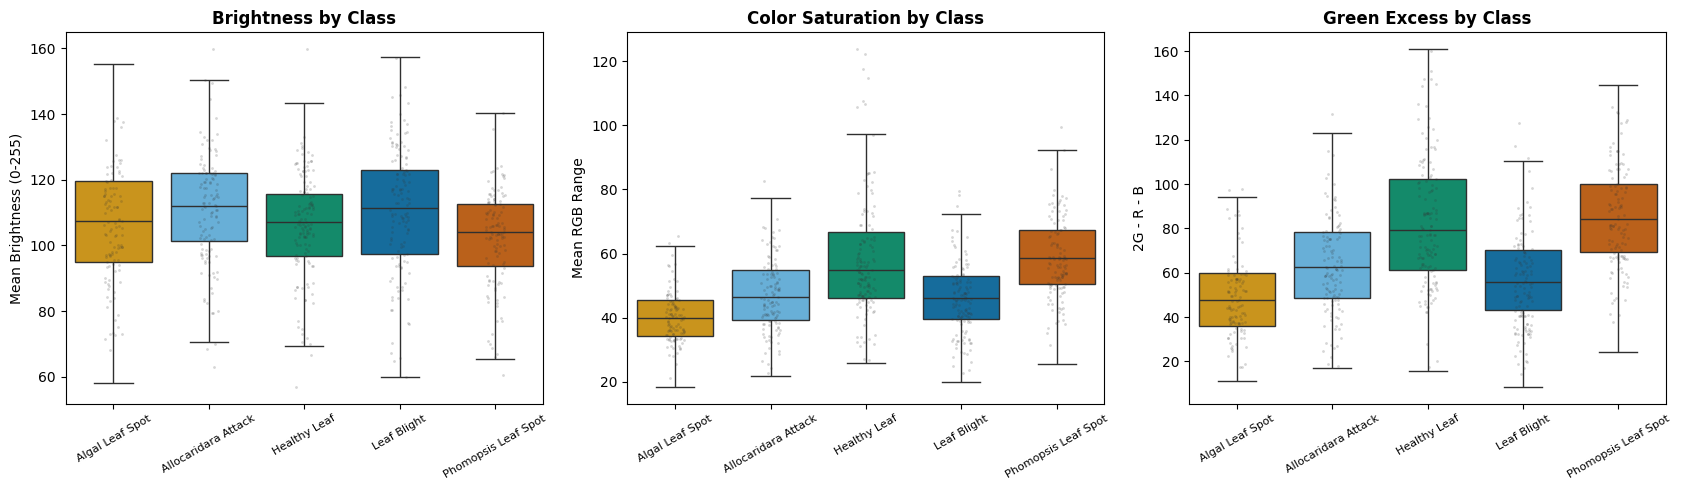

Saved → visualizations/eda/full_dataset_visual_feature_profile.png


In [9]:
# Summarize visual/statistical features over the full dataset
class_feature_profile = (
    manifest_df.groupby("class_label")
    .agg(
        n=("path", "size"),
        file_size_mean=("file_size_kb", "mean"),
        file_size_std=("file_size_kb", "std"),
        brightness_mean=("brightness", "mean"),
        brightness_std=("brightness", "std"),
        contrast_mean=("contrast", "mean"),
        saturation_mean=("saturation", "mean"),
        mean_r=("mean_r", "mean"),
        mean_g=("mean_g", "mean"),
        mean_b=("mean_b", "mean"),
        green_excess=("green_excess", "mean"),
    )
    .round(2)
)

display(class_feature_profile)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
plot_specs = [
    ("brightness", "Mean Brightness (0-255)", "Brightness by Class"),
    ("saturation", "Mean RGB Range", "Color Saturation by Class"),
    ("green_excess", "2G - R - B", "Green Excess by Class"),
]
for ax, (col, ylabel, title) in zip(axes, plot_specs):
    sns.boxplot(data=manifest_df, x="class_label", y=col, palette=CLASS_COLORS, ax=ax, showfliers=False)
    sns.stripplot(data=manifest_df.sample(min(600, len(manifest_df)), random_state=42),
                  x="class_label", y=col, color="#333333", alpha=0.20, size=2, ax=ax)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30, labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(EDA_VIZ_DIR, "full_dataset_visual_feature_profile.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → visualizations/eda/full_dataset_visual_feature_profile.png")

**Nhận xét — Feature ảnh trên toàn bộ dataset:**

- **Quan sát chính:** *Allocaridara Attack* có brightness trung bình cao nhất (**111.04**), tiếp theo là *Leaf Blight* (**109.83**). *Phomopsis Leaf Spot* thấp nhất (**102.56**). Về màu, *Phomopsis Leaf Spot* có **green_excess cao nhất 85.57**, rất gần *Healthy Leaf* (**82.95**), trong khi *Algal Leaf Spot* thấp nhất (**48.61**).
- **Ý nghĩa:** Nhận xét “Healthy Leaf luôn xanh nhất/sáng nhất” không đúng hoàn toàn với toàn bộ dataset. Healthy có saturation cao (**58.92**) và blue thấp (**89.01**), nhưng *Phomopsis* còn có saturation/green_excess nhỉnh hơn một chút.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Màu xanh không đủ để tách Healthy khỏi Phomopsis; mô hình cần học texture, hình dạng đốm và vùng tổn thương. Augmentation màu nên dùng mức vừa phải để không xóa tín hiệu lesion.
- **Điểm cần lưu ý:** Các feature màu/độ sáng là thống kê toàn ảnh, có thể bị nền và vùng lá khỏe lấn át. Với mục tiêu segmentation, nên tiếp tục dùng attention/GradCAM và color prior ở vùng tổn thương thay vì toàn ảnh.

,feature,q1,q3,lower_bound,upper_bound,n_outliers,outlier_pct
0,file_size_kb,10.23,11.68,8.06,13.85,31,0.70
1,brightness,96.88,118.41,64.58,150.71,51,1.15
2,contrast,48.71,56.65,36.80,68.56,48,1.08
3,saturation,40.87,58.52,14.40,85.00,123,2.77
4,green_excess,49.12,85.12,-4.88,139.13,59,1.33


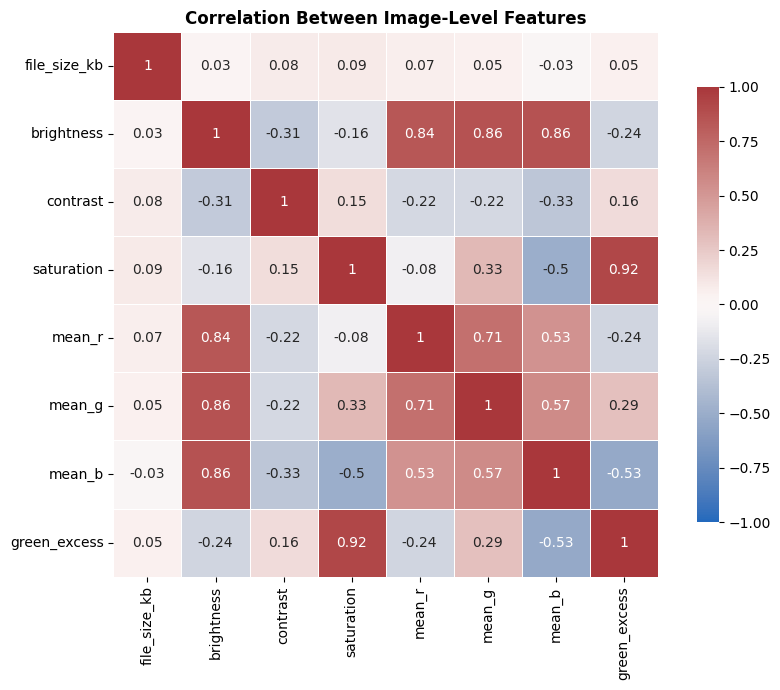

Saved → visualizations/eda/image_feature_correlation_heatmap.png


In [10]:
# Outlier and correlation analysis for image-level features
numeric_feature_cols = ["file_size_kb", "brightness", "contrast", "saturation", "green_excess"]
outlier_rows = []
for col in numeric_feature_cols:
    q1, q3 = manifest_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = int(((manifest_df[col] < lower) | (manifest_df[col] > upper)).sum())
    outlier_rows.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "lower_bound": lower,
        "upper_bound": upper,
        "n_outliers": n_outliers,
        "outlier_pct": n_outliers / len(manifest_df) * 100,
    })

outlier_summary = pd.DataFrame(outlier_rows).round(2)
display(outlier_summary)

corr_cols = ["file_size_kb", "brightness", "contrast", "saturation", "mean_r", "mean_g", "mean_b", "green_excess"]
corr_matrix = manifest_df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap="vlag", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Between Image-Level Features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(EDA_VIZ_DIR, "image_feature_correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → visualizations/eda/image_feature_correlation_heatmap.png")

**Nhận xét — Outlier và tương quan feature:**

- **Quan sát chính:** Outlier theo IQR xuất hiện nhiều nhất ở **saturation: 123 ảnh (2.77%)**, tiếp theo là **green_excess: 59 ảnh (1.33%)**, **brightness: 51 ảnh (1.15%)**, **contrast: 48 ảnh (1.08%)** và **file_size_kb: 31 ảnh (0.70%)**.
- **Ý nghĩa:** Tỉ lệ outlier thấp, không gợi ý lỗi dữ liệu hàng loạt. Các outlier saturation/green_excess nhiều hơn hợp lý vì ảnh bệnh có mức đổi màu và nền lá rất khác nhau.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Không nên xóa outlier tự động chỉ dựa trên thống kê màu toàn ảnh; nên xem ảnh đại diện hoặc dùng outlier list để kiểm tra nhãn/ảnh quá tối/quá sáng.
- **Điểm cần lưu ý:** Heatmap cho thấy **saturation và green_excess tương quan rất cao (0.92)**, trong khi file size gần như không tương quan với feature thị giác. Nếu tạo handcrafted baseline, không nên dùng đồng thời quá nhiều feature màu tương quan mạnh mà không regularization.

## Dataset Split Analysis

In [11]:
# Analyze split ratios
total_images = sum(len(v) for v in datasets.values())
train_ratio = len(datasets['train']) / total_images
val_ratio = len(datasets['val']) / total_images
test_ratio = len(datasets['test']) / total_images

print("Dataset split ratios:")
print(f"  Train: {train_ratio:.1%} ({len(datasets['train'])} images)")
print(f"  Validation: {val_ratio:.1%} ({len(datasets['val'])} images)")
print(f"  Test: {test_ratio:.1%} ({len(datasets['test'])} images)")

# Expected ratios (70/10/20)
expected_ratios = {'train': 0.7, 'val': 0.1, 'test': 0.2}
actual_ratios = {'train': train_ratio, 'val': val_ratio, 'test': test_ratio}
    
print("Ratio validation:")
for split, expected in expected_ratios.items():
    actual = actual_ratios[split]
    diff = abs(actual - expected)
    if diff < 0.01:  # Within 1% tolerance
        print(f"  {split}: ✅ {actual:.1%} (expected {expected:.1%})")
    else:
        print(f"  {split}: ⚠️  {actual:.1%} (expected {expected:.1%}) - difference: {diff:.1%}")

Dataset split ratios:
  Train: 70.0% (3104 images)
  Validation: 10.0% (443 images)
  Test: 20.1% (890 images)
Ratio validation:
  train: ✅ 70.0% (expected 70.0%)
  val: ✅ 10.0% (expected 10.0%)
  test: ✅ 20.1% (expected 20.0%)


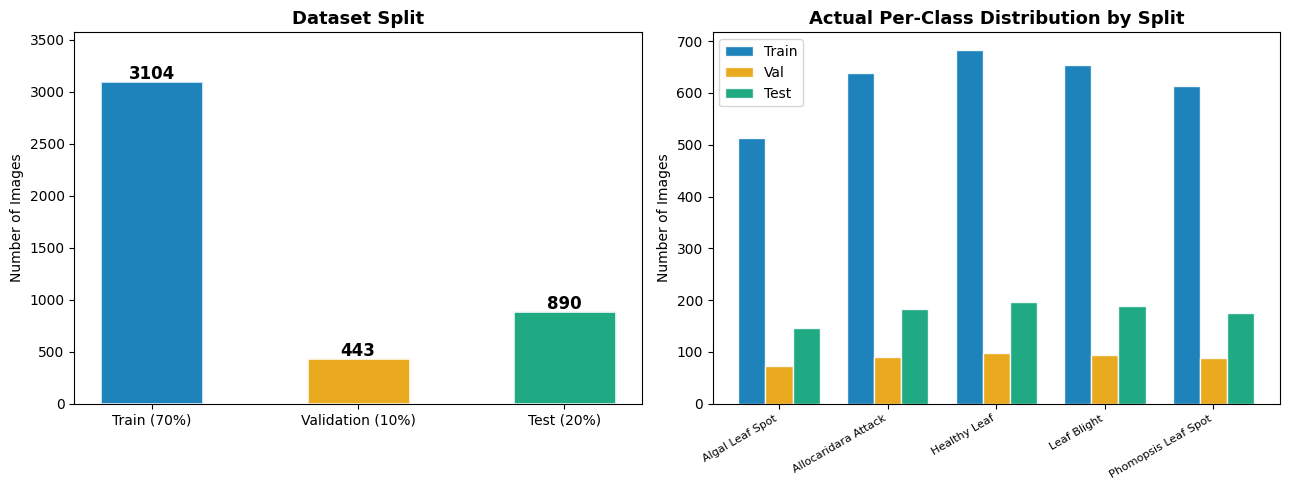

Saved → visualizations/eda/dataset_splits.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_s = ["#0072B2", "#E69F00", "#009E73"]

ax1 = axes[0]
splits = {"Train (70%)": len(datasets['train']), "Validation (10%)": len(datasets['val']), "Test (20%)": len(datasets['test'])}
bars = ax1.bar(splits.keys(), splits.values(), color=colors_s, edgecolor="white", linewidth=2, alpha=0.88, width=0.5)
for bar, cnt in zip(bars, splits.values()):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20, str(cnt),
             ha="center", fontsize=12, fontweight="bold")
ax1.set_title("Dataset Split", fontsize=13, fontweight="bold")
ax1.set_ylabel("Number of Images")
ax1.set_ylim(0, max(splits.values()) * 1.15)

ax2 = axes[1]
actual_split_counts = pd.crosstab(manifest_df["class_label"], manifest_df["split"]).reindex(CLASS_LABELS)
actual_split_counts = actual_split_counts[["train", "val", "test"]]
x = np.arange(len(CLASS_LABELS))
w = 0.25
for i, (sname, color) in enumerate(zip(["train", "val", "test"], colors_s)):
    ax2.bar(x + i * w, actual_split_counts[sname].values, w, label=sname.title(), color=color, alpha=0.88, edgecolor="white")
ax2.set_title("Actual Per-Class Distribution by Split", fontsize=13, fontweight="bold")
ax2.set_xticks(x + w)
ax2.set_xticklabels(CLASS_LABELS, rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("Number of Images")
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(EDA_VIZ_DIR, "dataset_splits.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → visualizations/eda/dataset_splits.png")

---
**Nhận xét — Phân chia tập dữ liệu:**

- **Quan sát chính:** Split thực tế là **3,104 / 443 / 890 ảnh**, tương ứng **70.0% / 10.0% / 20.1%**. Sai khác của test so với 20% chỉ khoảng **0.1 điểm phần trăm**.
- **Ý nghĩa:** Tỉ lệ train/val/test phù hợp cho fine-tuning classifier: train đủ lớn để học, validation đủ cho early stopping, test đủ để báo cáo kết quả cuối cùng.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Nên giữ nguyên split này xuyên suốt các notebook sau để tránh so sánh metric trên các tập khác nhau.
- **Điểm cần lưu ý:** Biểu đồ bên phải hiện dùng **số lượng split thực tế theo từng lớp** từ manifest. Mỗi lớp đều theo gần đúng 70/10/20, nên rủi ro skew do split thấp.

## Sample Image Visualization

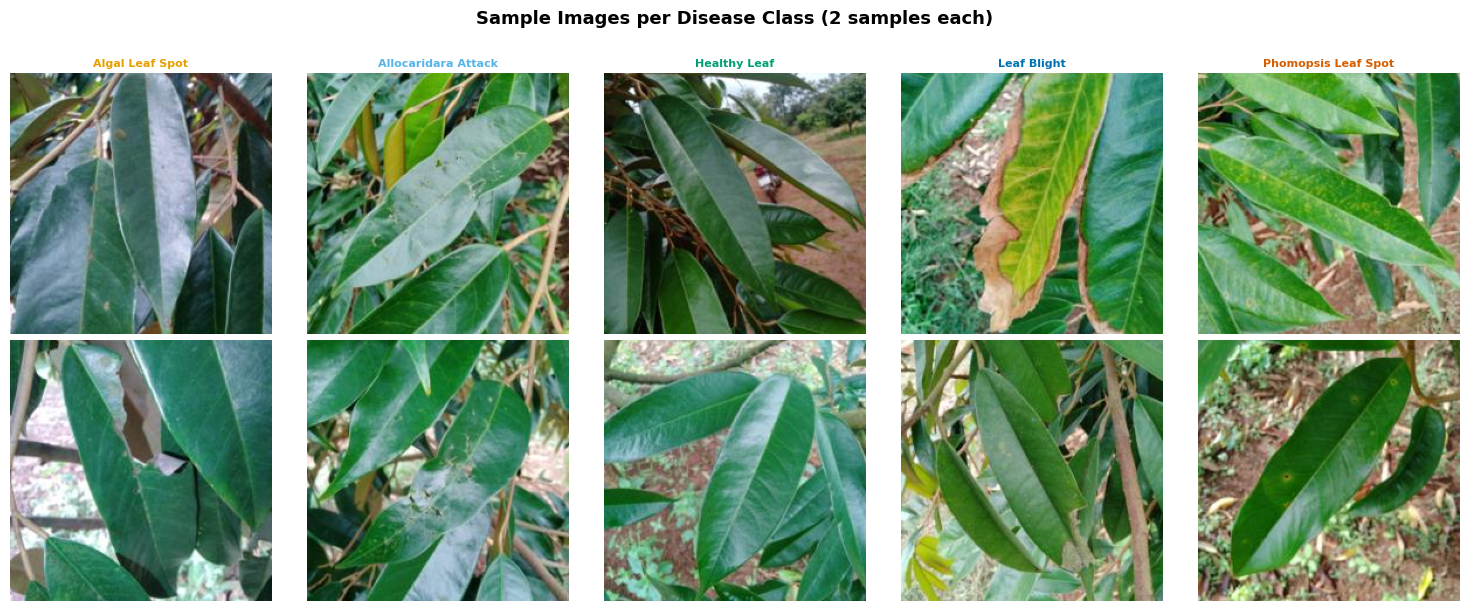

Saved → visualizations/eda/sample_images_per_class.png


In [13]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Images per Disease Class (2 samples each)", fontsize=13, fontweight="bold", y=1.01)

raw_train_dir = Path(DATA_RAW_DIR) / "train"

for col, (cname, clabel, ccolor) in enumerate(zip(CLASS_NAMES, CLASS_LABELS, CLASS_COLORS)):
    img_dir = raw_train_dir / cname
    imgs = sorted(img_dir.glob("*.jpg"))[7:9] if img_dir.exists() else []
    for row in range(2):
        ax = axes[row][col]
        if row < len(imgs):
            try:
                ax.imshow(Image.open(imgs[row]).convert("RGB"))
            except:
                ax.set_facecolor(ccolor)
        else:
            ax.set_facecolor("#eeeeee")
        ax.axis("off")
        if row == 0:
            ax.set_title(clabel, fontsize=8, fontweight="bold", color=ccolor, pad=4)

plt.tight_layout()
plt.savefig(os.path.join(EDA_VIZ_DIR, "sample_images_per_class.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → visualizations/eda/sample_images_per_class.png")

---
**Nhận xét — Ảnh mẫu theo lớp:**

- **Quan sát chính:** Ảnh mẫu cho thấy các lớp bệnh khác nhau không chỉ ở màu mà còn ở hình thái tổn thương: *Algal Leaf Spot* có đốm tròn/vàng-nâu, *Allocaridara Attack* có vết phá lá/lỗ không đều, *Leaf Blight* có mảng cháy lớn, *Phomopsis Leaf Spot* có đốm nhỏ/tối, còn *Healthy Leaf* chủ yếu là nền xanh ít tổn thương.
- **Ý nghĩa:** Đây là bài toán thị giác có cả tín hiệu màu, texture và hình dạng vùng bệnh; chỉ dùng thống kê màu toàn ảnh sẽ bỏ sót nhiều đặc trưng quan trọng.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Augmentation hình học như flip/rotation là hợp lý vì bệnh không phụ thuộc hướng ảnh. Tuy nhiên crop quá mạnh có thể làm mất lesion nhỏ ở *Phomopsis* hoặc *Algal Leaf Spot*.
- **Điểm cần lưu ý:** *Phomopsis Leaf Spot* và *Algal Leaf Spot* có hình thái đốm tương tự, nên cần theo dõi cặp lớp này trong confusion matrix và GradCAM.

## RGB Color Channel Analysis

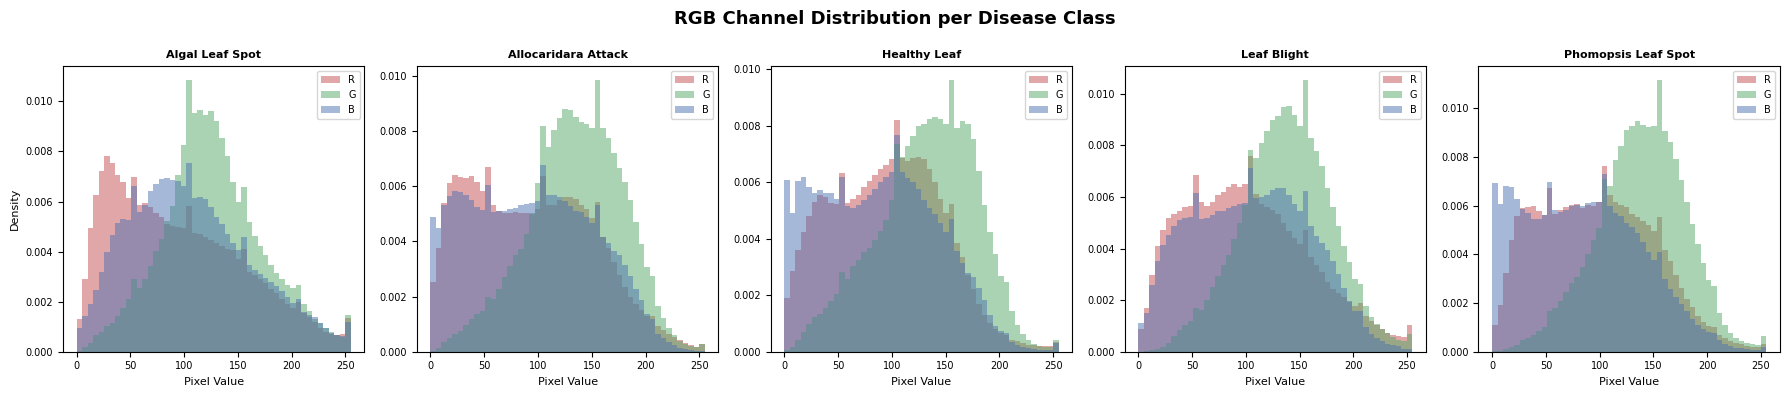

Saved → visualizations/eda/rgb_histogram_per_class.png
Observation: Healthy Leaf has the highest Green channel — characteristic of healthy foliage


In [14]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("RGB Channel Distribution per Disease Class", fontsize=13, fontweight="bold")

raw_train_dir = Path(DATA_RAW_DIR) / "train"

for col, (cname, clabel) in enumerate(zip(CLASS_NAMES, CLASS_LABELS)):
    ax = axes[col]
    img_dir = raw_train_dir / cname
    imgs = sorted(img_dir.glob("*.jpg"))[:20] if img_dir.exists() else []
    ch_data = [[], [], []]
    for imgp in imgs:
        try:
            arr = np.array(Image.open(imgp).convert("RGB"))
            for ch in range(3):
                ch_data[ch].extend(arr[:, :, ch].flatten().tolist())
        except:
            pass
    for ch, (d, c, n) in enumerate(zip(ch_data, ["#C44E52", "#55A868", "#4C72B0"], ["R", "G", "B"])):
        if d:
            ax.hist(d, bins=50, color=c, alpha=0.5, label=n, density=True)
    ax.set_title(clabel, fontsize=8, fontweight="bold")
    ax.set_xlabel("Pixel Value", fontsize=8)
    if col == 0:
        ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(EDA_VIZ_DIR, "rgb_histogram_per_class.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → visualizations/eda/rgb_histogram_per_class.png")
print("Observation: Healthy Leaf has the highest Green channel — characteristic of healthy foliage")

---
**Nhận xét — Histogram kênh màu RGB:**

- **Quan sát chính:** Histogram cho thấy kênh **G** thường dịch phải so với R/B ở hầu hết lớp, đúng với dữ liệu ảnh lá. Các lớp bệnh vẫn giữ nhiều vùng xanh, nên phân phối màu giữa lớp bệnh và lớp Healthy bị chồng lấp đáng kể.
- **Ý nghĩa:** Tín hiệu màu có giá trị nhưng không tạo ranh giới tuyến tính đơn giản giữa các lớp. Một ảnh bệnh có thể vẫn xanh mạnh nếu vùng tổn thương nhỏ so với toàn bộ lá.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Không nên dùng threshold màu toàn ảnh để phân loại. CNN/attention cần học vùng cục bộ; color prior nên áp dụng như hỗ trợ segmentation hơn là luật phân loại cứng.
- **Điểm cần lưu ý:** Histogram cell này chỉ lấy **20 ảnh train đầu mỗi lớp**, nên xu hướng cần được đối chiếu với bảng feature toàn bộ dataset ở phần sau.

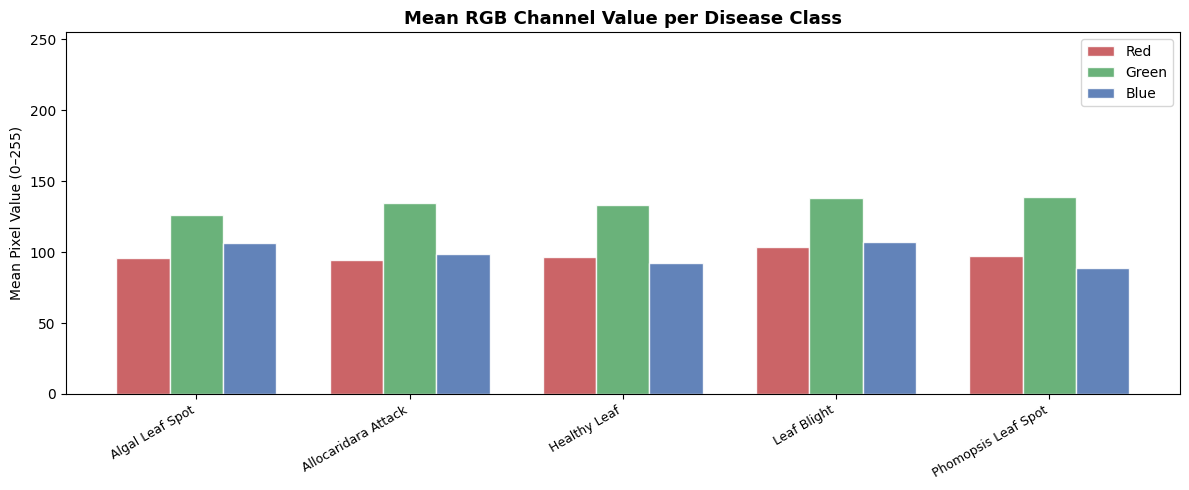

Saved → visualizations/eda/mean_rgb_per_class.png
Algal Leaf Spot: R=95.8, G=125.8, B=106.6
Allocaridara Attack: R=94.4, G=134.5, B=98.9
Healthy Leaf: R=96.4, G=133.0, B=92.1
Leaf Blight: R=103.5, G=137.8, B=107.2
Phomopsis Leaf Spot: R=97.2, G=138.6, B=88.5


In [15]:
COLOR_R = "#C44E52"
COLOR_G = "#55A868"
COLOR_B = "#4C72B0"

fig, ax = plt.subplots(figsize=(12, 5))
mean_r, mean_g, mean_b = [], [], []

for cname in CLASS_NAMES:
    img_dir = raw_train_dir / cname
    imgs = sorted(img_dir.glob("*.jpg"))[:30] if img_dir.exists() else []
    rs, gs, bs = [], [], []
    for imgp in imgs:
        try:
            arr = np.array(Image.open(imgp).convert("RGB"), dtype=np.float32)
            rs.append(arr[:, :, 0].mean())
            gs.append(arr[:, :, 1].mean())
            bs.append(arr[:, :, 2].mean())
        except:
            pass
    mean_r.append(np.mean(rs) if rs else 0)
    mean_g.append(np.mean(gs) if gs else 0)
    mean_b.append(np.mean(bs) if bs else 0)

x = np.arange(len(CLASS_LABELS))
w = 0.25
ax.bar(x - w, mean_r, w, label="Red",   color=COLOR_R, alpha=0.88, edgecolor="white")
ax.bar(x,     mean_g, w, label="Green", color=COLOR_G, alpha=0.88, edgecolor="white")
ax.bar(x + w, mean_b, w, label="Blue",  color=COLOR_B, alpha=0.88, edgecolor="white")
ax.set_title("Mean RGB Channel Value per Disease Class", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS, rotation=30, ha="right", fontsize=9)
ax.legend()
ax.set_ylim(0, 255)
ax.set_ylabel("Mean Pixel Value (0–255)")

plt.tight_layout()
plt.savefig(os.path.join(EDA_VIZ_DIR, "mean_rgb_per_class.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → visualizations/eda/mean_rgb_per_class.png")
for clabel, r, g, b in zip(CLASS_LABELS, mean_r, mean_g, mean_b):
    print(f"{clabel}: R={r:.1f}, G={g:.1f}, B={b:.1f}")

---
**Nhận xét — Giá trị trung bình kênh màu RGB:**

- **Quan sát chính:** Trên mẫu 30 ảnh/lớp của cell này, kênh **G cao nhất** là *Phomopsis Leaf Spot* (**138.6**), sau đó *Leaf Blight* (**137.8**), *Allocaridara Attack* (**134.5**) và *Healthy Leaf* (**133.0**). *Healthy Leaf* nổi bật hơn ở **B thấp (92.1)** và khoảng cách G-B lớn, không phải ở G tuyệt đối cao nhất.
- **Ý nghĩa:** Nhận định “Healthy Leaf có G cao nhất” không được số liệu cell này ủng hộ. Điều phân biệt Healthy có thể là sắc xanh bão hòa và ít vùng nâu/tối hơn, chứ không đơn giản là mean G cao.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Nếu dùng feature màu thủ công, nên cân nhắc các chỉ số tương đối như `green_excess = 2G - R - B`, saturation hoặc tỉ lệ kênh thay vì chỉ dùng mean G.
- **Điểm cần lưu ý:** Cell này dùng mẫu 30 ảnh/lớp; phần “Full-Dataset Image Feature Profile” bên dưới cung cấp kết luận đáng tin hơn trên toàn bộ **4,437 ảnh**.

## Image Statistics Analysis

In [16]:
# Analyze image dimensions and properties
image_stats = {
    'widths': [],
    'heights': [],
    'aspect_ratios': [],
    'file_sizes': []
}

# Sample a subset for analysis (to avoid loading all images)
sample_size = min(100, len(datasets['train']))
sample_indices = np.random.choice(len(datasets['train']), sample_size, replace=False)

print(f"Analyzing {sample_size} sample images...")

for idx in sample_indices:
    img_obj = datasets['train'][idx]
    
    # Get original dimensions
    width, height = img_obj.original_shape[:2]
    aspect_ratio = width / height if height > 0 else 0
    
    # Get file size
    try:
        file_size = os.path.getsize(img_obj.image_path) / 1024  # KB
    except:
        file_size = 0
    
    image_stats['widths'].append(width)
    image_stats['heights'].append(height)
    image_stats['aspect_ratios'].append(aspect_ratio)
    image_stats['file_sizes'].append(file_size)

# Calculate statistics
stats_summary = {}
for key, values in image_stats.items():
    if values:
        stats_summary[key] = {
            'mean': np.mean(values),
            'std': np.std(values),
            'min': np.min(values),
            'max': np.max(values),
            'median': np.median(values)
        }

print("\nImage Statistics Summary:")
for stat_name, stat_values in stats_summary.items():
    print(f"\n{stat_name.upper()}:")
    for metric, value in stat_values.items():
        if 'size' in stat_name:
            print(f"  {metric}: {value:.1f} KB")
        else:
            print(f"  {metric}: {value:.1f}")

Analyzing 100 sample images...

Image Statistics Summary:

WIDTHS:
  mean: 224.0
  std: 0.0
  min: 224.0
  max: 224.0
  median: 224.0

HEIGHTS:
  mean: 224.0
  std: 0.0
  min: 224.0
  max: 224.0
  median: 224.0

ASPECT_RATIOS:
  mean: 1.0
  std: 0.0
  min: 1.0
  max: 1.0
  median: 1.0

FILE_SIZES:
  mean: 11.1 KB
  std: 1.0 KB
  min: 9.0 KB
  max: 14.6 KB
  median: 11.1 KB


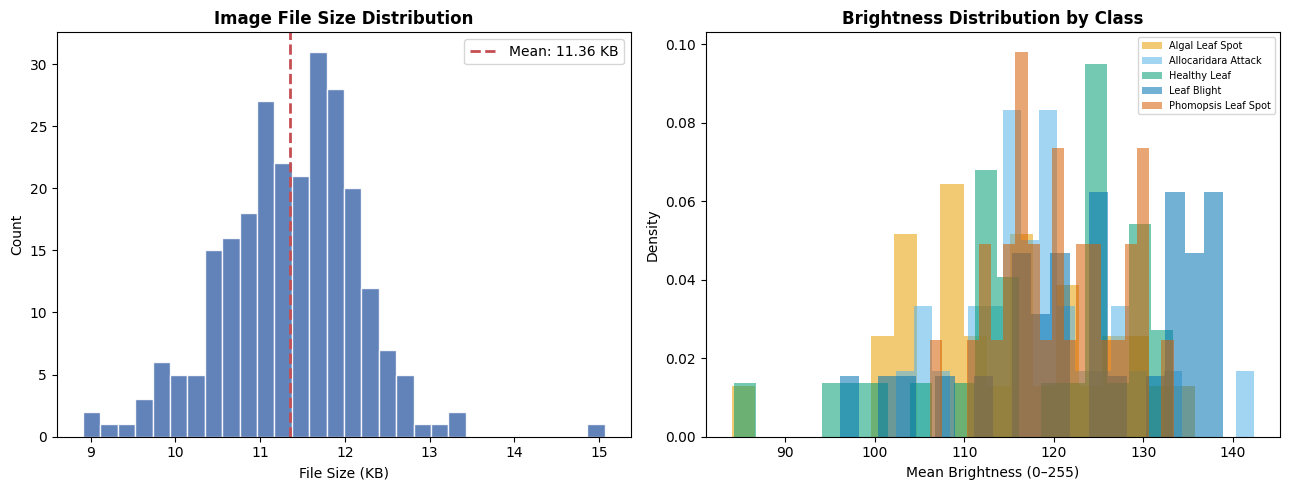

Saved → visualizations/eda/file_size_and_brightness.png
File size — Mean: 11.36 KB, Std: 0.80 KB, Min: 8.91 KB, Max: 15.07 KB


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

file_sizes = []
for cname in CLASS_NAMES:
    img_dir = raw_train_dir / cname
    if img_dir.exists():
        for imgp in list(img_dir.glob("*.jpg"))[:50]:
            file_sizes.append(os.path.getsize(imgp) / 1024)

ax1 = axes[0]
ax1.hist(file_sizes, bins=30, color="#4C72B0", edgecolor="white", alpha=0.88)
ax1.axvline(x=np.mean(file_sizes), color="#C44E52", linestyle="--", linewidth=2,
            label=f"Mean: {np.mean(file_sizes):.2f} KB")
ax1.set_title("Image File Size Distribution", fontsize=12, fontweight="bold")
ax1.set_xlabel("File Size (KB)")
ax1.set_ylabel("Count")
ax1.legend()

ax2 = axes[1]
brightness_data = {}
for cname, clabel, ccolor in zip(CLASS_NAMES, CLASS_LABELS, CLASS_COLORS):
    img_dir = raw_train_dir / cname
    if img_dir.exists():
        brightness = []
        for imgp in list(img_dir.glob("*.jpg"))[:30]:
            try:
                arr = np.array(Image.open(imgp).convert("L"), dtype=np.float32)
                brightness.append(arr.mean())
            except:
                pass
        if brightness:
            brightness_data[clabel] = brightness
            ax2.hist(brightness, bins=20, color=ccolor, alpha=0.55, label=clabel, density=True)
ax2.set_title("Brightness Distribution by Class", fontsize=12, fontweight="bold")
ax2.set_xlabel("Mean Brightness (0–255)")
ax2.set_ylabel("Density")
ax2.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(EDA_VIZ_DIR, "file_size_and_brightness.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → visualizations/eda/file_size_and_brightness.png")
print(f"File size — Mean: {np.mean(file_sizes):.2f} KB, Std: {np.std(file_sizes):.2f} KB, "
      f"Min: {min(file_sizes):.2f} KB, Max: {max(file_sizes):.2f} KB")

---
**Nhận xét — Kích thước file & Độ sáng:**

- **Quan sát chính:** Với mẫu trong cell này, file size tập trung quanh **11.36 KB**, std **0.80 KB**, min **8.91 KB**, max **15.07 KB**. Cell thống kê trước đó trên 100 ảnh train cũng cho thấy ảnh đều là **224x224**, aspect ratio **1.0**.
- **Ý nghĩa:** Dung lượng và kích thước ảnh khá đồng nhất, phản ánh dữ liệu đã qua chuẩn hóa/nén nhất quán.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Resize về 224x224 trong DataLoader sẽ không làm thay đổi kích thước gốc hiện tại, nhưng vẫn giữ pipeline an toàn nếu sau này thêm ảnh mới khác kích thước.
- **Điểm cần lưu ý:** Biểu đồ brightness trong cell này chỉ dùng **30 ảnh đầu mỗi lớp**; vì vậy các kết luận về lớp sáng/tối cần ưu tiên bảng full-dataset thay vì dựa riêng vào subset này.

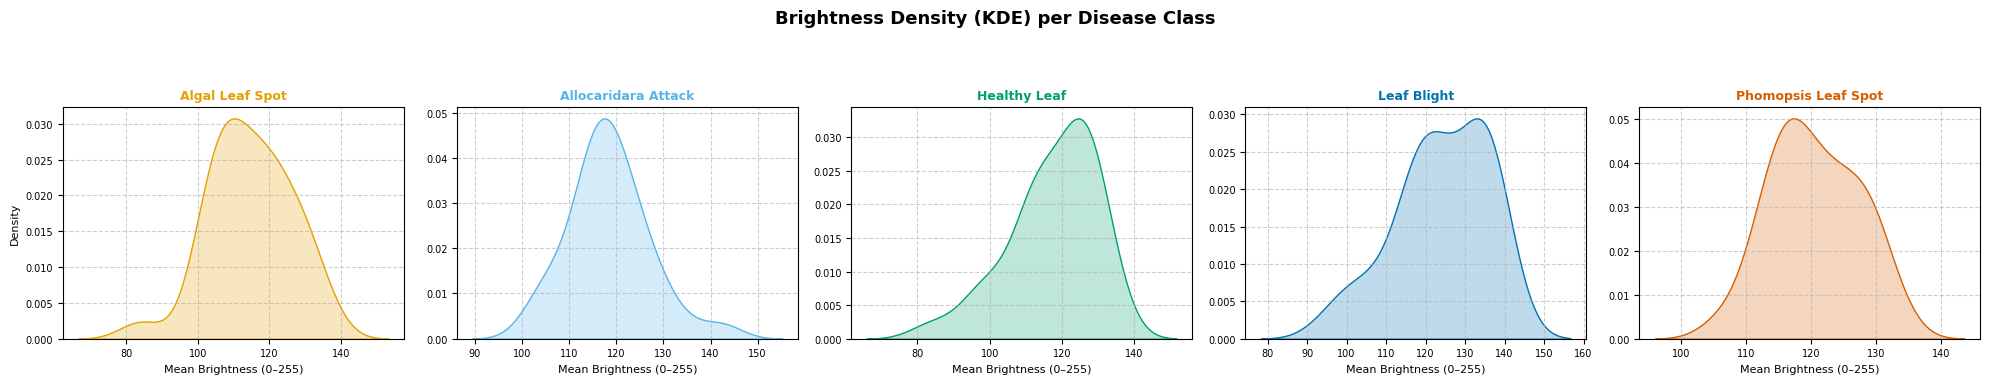

Saved → visualizations/eda/brightness_kde_per_class.png


In [18]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(20, 4))
fig.suptitle("Brightness Density (KDE) per Disease Class", fontsize=13, fontweight="bold")

for i, (clabel, ccolor) in enumerate(zip(CLASS_LABELS, CLASS_COLORS)):
    ax = axes[i]
    if clabel in brightness_data:
        sns.kdeplot(brightness_data[clabel], fill=True, color=ccolor, ax=ax)
        ax.set_title(clabel, fontsize=9, fontweight="bold", color=ccolor)
        ax.set_xlabel("Mean Brightness (0–255)", fontsize=8)
        ax.set_ylabel("Density" if i == 0 else "", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, linestyle="--", alpha=0.6)
    else:
        ax.set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.savefig(os.path.join(EDA_VIZ_DIR, "brightness_kde_per_class.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → visualizations/eda/brightness_kde_per_class.png")

---
**Nhận xét — Phân phối độ sáng theo lớp (KDE):**

- **Quan sát chính:** KDE cho thấy phân phối độ sáng giữa các lớp có chồng lấp mạnh, nhưng độ rộng phân phối khác nhau. Các lớp bệnh có xu hướng xuất hiện cả vùng sáng và tối do nền lá, mô hoại tử và vùng tổn thương.
- **Ý nghĩa:** Độ sáng là tín hiệu bổ trợ, không đủ để phân tách độc lập 5 lớp. Việc ánh sáng/nền thay đổi có thể làm mô hình học shortcut nếu không augmentation cẩn thận.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Nên giữ `ColorJitter` nhẹ như notebook training hiện dùng, đồng thời theo dõi performance trên các ảnh quá tối/quá sáng.
- **Điểm cần lưu ý:** KDE này dựa trên `brightness_data` từ cell trước, tức subset 30 ảnh/lớp. Phần outlier/full-dataset bên dưới định lượng lại độ sáng trên toàn bộ dataset.

## Data Processing Pipeline Test

In [19]:
# Test data loading pipeline
print("Testing data loading pipeline...")

# Create data loaders for each split
train_loader = data_loader.get_data_loader('train', is_training=True)
val_loader = data_loader.get_data_loader('val', is_training=False)
test_loader = data_loader.get_data_loader('test', is_training=False)

print("✅ Data loaders created successfully")

# Test batch loading
try:
    # Get one batch from training set
    batch = next(iter(train_loader))
    images, labels = batch['image'], batch['label']
    
    print(f"Batch shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Image value range: [{images.min():.3f}, {images.max():.3f}]")
    print(f"Label range: [{labels.min()}, {labels.max()}]")
    
    # Check normalization (ImageNet stats)
    mean = images.mean(dim=[0, 2, 3])
    std = images.std(dim=[0, 2, 3])
    print(f"Channel means: {mean}")
    print(f"Channel stds: {std}")
    
    print("✅ Data loading pipeline working correctly")
    
except Exception as e:
    print(f"❌ Error in data loading pipeline: {e}")

Testing data loading pipeline...
✅ Data loaders created successfully


Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Image value range: [-2.118, 2.640]
Label range: [0, 4]
Channel means: tensor([-0.6184,  0.0006, -0.3201])
Channel stds: tensor([1.0298, 1.0201, 1.0387])
✅ Data loading pipeline working correctly


---
**Nhận xét — Kiểm tra DataLoader/Pipeline:**

- **Quan sát chính:** DataLoader tạo batch thành công với shape **[32, 3, 224, 224]**, label shape **[32]**, label nằm trong khoảng **0-4** và pixel sau normalize nằm khoảng **[-2.118, 2.640]**.
- **Ý nghĩa:** Tensor đầu vào đúng định dạng PyTorch cho mô hình CNN; nhãn phù hợp bài toán 5 lớp.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Normalize theo ImageNet đang hoạt động; channel mean/std sau normalize không cần bằng 0/1 tuyệt đối vì đây chỉ là một batch có augmentation.
- **Điểm cần lưu ý:** Với Windows, `num_workers=0` trong utils là lựa chọn ổn định. Khi training lâu, có thể benchmark lại I/O nếu chuyển sang Linux/GPU server.

## Save Dataset Information

In [20]:
# Save dataset split information
split_info_path = os.path.join(DATA_PROCESSED_DIR, "dataset_split.json")
data_loader.save_split_info(split_info_path)
print(f"✅ Dataset split information saved to: {split_info_path}")

# Save dataset statistics
stats_info = {
    'timestamp': datetime.now().isoformat(),
    'total_images': sum(len(v) for v in datasets.values()),
    'split_counts': {k: len(v) for k, v in datasets.items()},
    'class_distribution': class_distribution,
    'image_statistics': stats_summary,
    'integrity_summary': integrity_summary.to_dict(orient='records'),
    'class_feature_profile': class_feature_profile.reset_index().to_dict(orient='records'),
    'outlier_summary': outlier_summary.to_dict(orient='records'),
    'manifest_path': manifest_path,
    'data_loader_config': {
        'batch_size': data_loader.batch_size,
        'image_size': data_loader.image_size,
        'random_seed': data_loader.random_seed
    }
}

stats_path = os.path.join(DATA_PROCESSED_DIR, "dataset_statistics.json")
with open(stats_path, 'w') as f:
    json.dump(stats_info, f, indent=2, default=str)
    
print(f"✅ Dataset statistics saved to: {stats_path}")

✅ Dataset split information saved to: data/processed\dataset_split.json
✅ Dataset statistics saved to: data/processed\dataset_statistics.json


---
**Nhận xét — Lưu artifact EDA:**

- **Quan sát chính:** Notebook lưu `dataset_split.json`, `dataset_statistics.json` và manifest mới `image_manifest.csv` vào `data/processed/`; các biểu đồ EDA được lưu vào `visualizations/eda/`.
- **Ý nghĩa:** Các notebook sau có thể tái sử dụng cùng split và thống kê EDA mà không cần quét lại toàn bộ ảnh mỗi lần.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Nên version-control hoặc snapshot các artifact này cùng kết quả training để truy vết metric về đúng dữ liệu nguồn.
- **Điểm cần lưu ý:** `image_id` trong `dataset_split.json` có timestamp khi chạy notebook, nên không nên dùng nó làm khóa ổn định; dùng `path`, `filename`, `class_label` hoặc hash sẽ đáng tin hơn.

## Summary and Next Steps

In [21]:
print("=" * 60)
print("DATA EXPLORATION SUMMARY")
print("=" * 60)

print(f"Total images processed: {sum(len(v) for v in datasets.values())}")
print(f"Number of classes: {len(class_distribution)}")
print(f"Train/Val/Test split: {len(datasets['train'])}/{len(datasets['val'])}/{len(datasets['test'])}")

print("\nClass distribution:")
for class_id, count in class_distribution.items():
    percentage = count / sum(class_distribution.values()) * 100
    print(f"  {CLASS_LABELS[class_id]}: {count} images ({percentage:.1f}%)")

print("\nKey audit results:")
print(f"  Unreadable files: {int((~manifest_df['readable']).sum())}")
print(f"  Unique image sizes: {manifest_df[['width', 'height']].drop_duplicates().shape[0]}")
print(f"  Exact duplicate image rows: {len(exact_duplicate_images)}")
print(f"  Cross-split hash leakage groups: {len(cross_split_hash_leakage)}")
print(f"  Cross-split filename overlap groups: {len(cross_split_filename_overlap)}")

print("\nRecommended next steps before modeling:")
print("1. Review the two duplicated Leaf Blight test images and remove one if reporting final test metrics.")
print("2. Add near-duplicate audit with perceptual hash or image embeddings.")
print("3. Keep macro-F1, per-class recall, and confusion matrix as primary classifier diagnostics.")
print("4. Inspect GradCAM failures for Algal Leaf Spot vs Phomopsis Leaf Spot after baseline training.")

print("\n" + "=" * 60)

DATA EXPLORATION SUMMARY
Total images processed: 4437
Number of classes: 5
Train/Val/Test split: 3104/443/890

Class distribution:
  Algal Leaf Spot: 733 images (16.5%)
  Allocaridara Attack: 913 images (20.6%)
  Healthy Leaf: 976 images (22.0%)
  Leaf Blight: 937 images (21.1%)
  Phomopsis Leaf Spot: 878 images (19.8%)

Key audit results:
  Unreadable files: 0
  Unique image sizes: 1
  Exact duplicate image rows: 2
  Cross-split hash leakage groups: 0
  Cross-split filename overlap groups: 0

Recommended next steps before modeling:
1. Review the two duplicated Leaf Blight test images and remove one if reporting final test metrics.
2. Add near-duplicate audit with perceptual hash or image embeddings.
3. Keep macro-F1, per-class recall, and confusion matrix as primary classifier diagnostics.
4. Inspect GradCAM failures for Algal Leaf Spot vs Phomopsis Leaf Spot after baseline training.



---
**Nhận xét — Tổng kết EDA:**

- **Quan sát chính:** Dataset đủ 5 lớp, gần cân bằng, split đúng 70/10/20, không có file hỏng và không có leakage exact hash/filename giữa train-val-test. Vấn đề dữ liệu cụ thể nhất là **1 cặp duplicate exact trong test/Leaf Blight**.
- **Ý nghĩa:** Dữ liệu đủ sạch để bắt đầu modeling baseline, nhưng test set nên được rà soát duplicate trước khi chốt kết quả luận văn.
- **Hàm ý cho tiền xử lý/mô hình hóa:** Baseline EfficientNet-B0 là hợp lý; ưu tiên augmentation nhẹ về màu/hình học, macro-F1, confusion matrix và GradCAM để phân tích lỗi.
- **Điểm cần lưu ý:** Các lớp có phân phối màu chồng lấp, đặc biệt Healthy và Phomopsis đều có tín hiệu xanh mạnh; mô hình cần học lesion-level cues thay vì shortcut màu toàn ảnh.